In [1]:
# Install Required Libraries
%pip install tensorflow matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

2026-05-06 20:51:53.359900: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 20:51:53.385030: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load MNIST Dataset

(X_train, _), (X_test, _) = mnist.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


In [3]:
# Normalize Data

X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Reshape Data

X_train = np.reshape(
    X_train,
    (len(X_train), 28, 28, 1)
)

X_test = np.reshape(
    X_test,
    (len(X_test), 28, 28, 1)
)

print("New Training Shape:", X_train.shape)

New Training Shape: (60000, 28, 28, 1)


In [4]:
# Build Convolutional Autoencoder

input_img = Input(shape=(28,28,1))

# Encoder

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    16,
    (3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

# Decoder

x = Conv2D(
    16,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

# Autoencoder Model

autoencoder = Model(
    input_img,
    decoded
)

In [5]:
# Compile Model

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Display Model Summary

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train Autoencoder

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/10
 10/469 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.6775   

2026-05-06 20:52:55.622427: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1300 - val_loss: 0.0807
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0781 - val_loss: 0.0750
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0746 - val_loss: 0.0731
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0729 - val_loss: 0.0716
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0717 - val_loss: 0.0706
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0708 - val_loss: 0.0698
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0701 - val_loss: 0.0694
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0696 - val_loss: 0.0689
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0691 - val_loss: 0.0684
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0687 - val_loss: 0.0681


In [7]:
# Predict/Reconstruct Images

decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


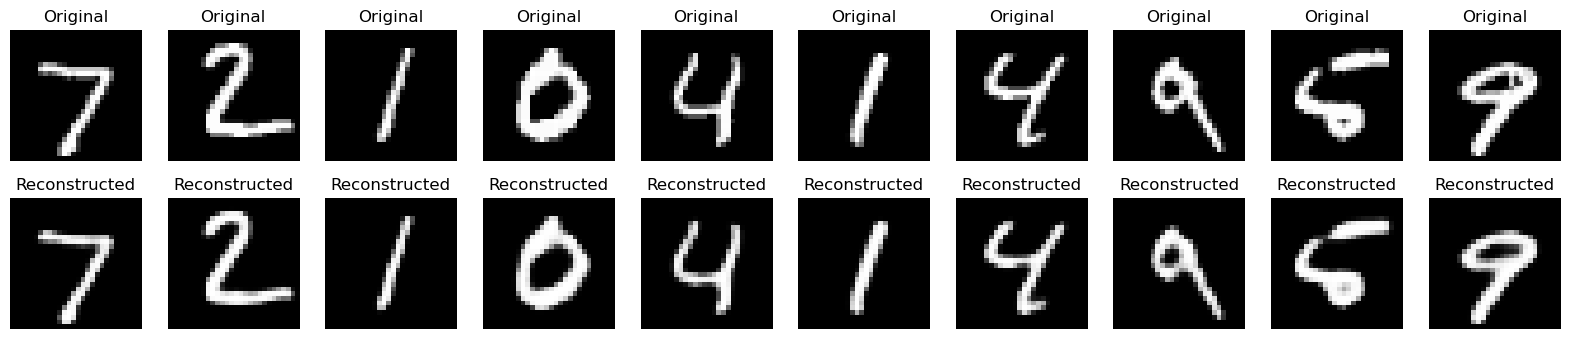

In [8]:
# Display Original and Reconstructed Images

n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original Image

    ax = plt.subplot(2,n,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Original")

    plt.axis('off')

    # Reconstructed Image

    ax = plt.subplot(2,n,i+1+n)

    plt.imshow(
        decoded_imgs[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Reconstructed")

    plt.axis('off')

plt.show()